In [1]:
import random

import numpy as np
import scienceplots
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# plt.style.use(["science", "no-latex"])

seed = 42

random.seed(seed)
np.random.seed(seed)

In [2]:
# Parameters
def sample_gmm(weights, means, cov, n_samples=1000):
    """Sample from the Gaussian mixture model."""
    n1 = np.random.binomial(n_samples, weights[0])
    n2 = n_samples - n1
    
    samples1 = np.random.multivariate_normal(means[0], cov, size=n1)
    samples2 = np.random.multivariate_normal(means[1], cov, size=n2)
    
    return np.vstack([samples1, samples2])


def gmm_pdf(x, weights, means, cov):
    """Compute mixture density at point(s) x (shape: (..., 2))."""
    p = 0.0
    for w, m in zip(weights, means):
        p += w * multivariate_normal.pdf(x, mean=m, cov=cov)
    return p


def gmm_score(x, weights, means, cov):
    """
    Compute score = ∇ log p(x).
    x: array of shape (2,)
    """
    num = np.zeros(2)
    denom = 0.0
    
    for w, m in zip(weights, means):
        pdf_val = multivariate_normal.pdf(x, mean=m, cov=cov)
        inv_cov = np.linalg.inv(cov)
        num += w * pdf_val * (-inv_cov @ (x - m))
        denom += w * pdf_val
    
    return num / denom


def langevin_dynamics(x0, weights, means, cov, n_steps=1000, eps=0.05):
    traj = [x0]
    x = x0.copy()
    for _ in range(n_steps):
        score = gmm_score(x, weights, means, cov)
        noise = np.random.randn(2)
        x = x + eps * score + np.sqrt(2 * eps) * noise
        traj.append(x)
    return np.array(traj)


def get_scores_and_contours(weights, means, cov, grid_x_v, grid_y_v):
    X, Y = np.meshgrid(grid_x_v, grid_y_v)
    
    U = np.zeros_like(X)
    V = np.zeros_like(X)
    Z = np.zeros_like(X)
    
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            grad = gmm_score(np.array([X[i, j], Y[i, j]]), weights, means, cov)
            U[i, j] = grad[0]
            V[i, j] = grad[1]

    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            Z[i, j] = gmm_pdf([X[i, j], Y[i, j]], weights, means, cov)

    return X, Y, Z, U, V

## GAUSSIANS ARE SEPARATED

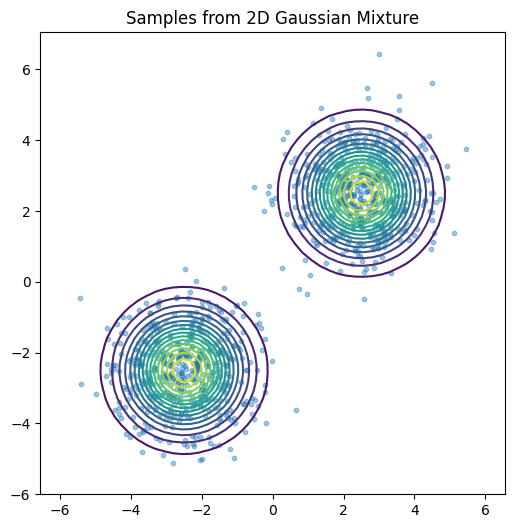

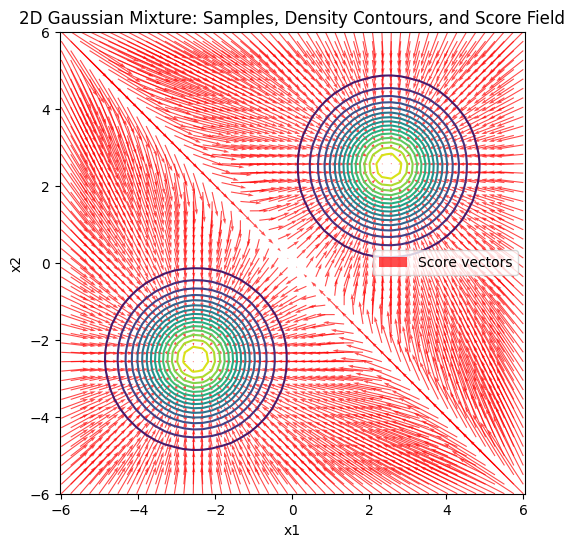

In [4]:
means = [np.array([2.5, 2.5]), np.array([-2.5, -2.5])]
cov = np.array([[1.0, 0.0],
                [0.0, 1.0]])   # same covariance for both
weights = [0.5, 0.5]

# samples
samples = sample_gmm(weights, means, cov, 1000)

# contours and scores
grid_x_v = np.linspace(-6, 6, 50)
grid_y_v = np.linspace(-6, 6, 50)
X, Y, Z, U, V = get_scores_and_contours(weights, means, cov, grid_x_v, grid_y_v)

# Plot samples and contours
plt.figure(figsize=(6,6))
plt.contour(X, Y, Z, levels=15, cmap="viridis")
plt.scatter(samples[:,0], samples[:,1], s=10, alpha=0.4)
plt.title("Samples from 2D Gaussian Mixture")
plt.axis("equal")
plt.show()

# Contours and scores
plt.figure(figsize=(6,6))
plt.contour(X, Y, Z, levels=15, cmap="viridis")
plt.quiver(X, Y, U, V, color="red", angles="xy", scale_units="xy", scale=5, alpha=0.7, label="Score vectors")
plt.title("2D Gaussian Mixture: Samples, Density Contours, and Score Field")
plt.xlabel("x1")
plt.ylabel("x2")
plt.axis("equal")
plt.legend()
plt.show()

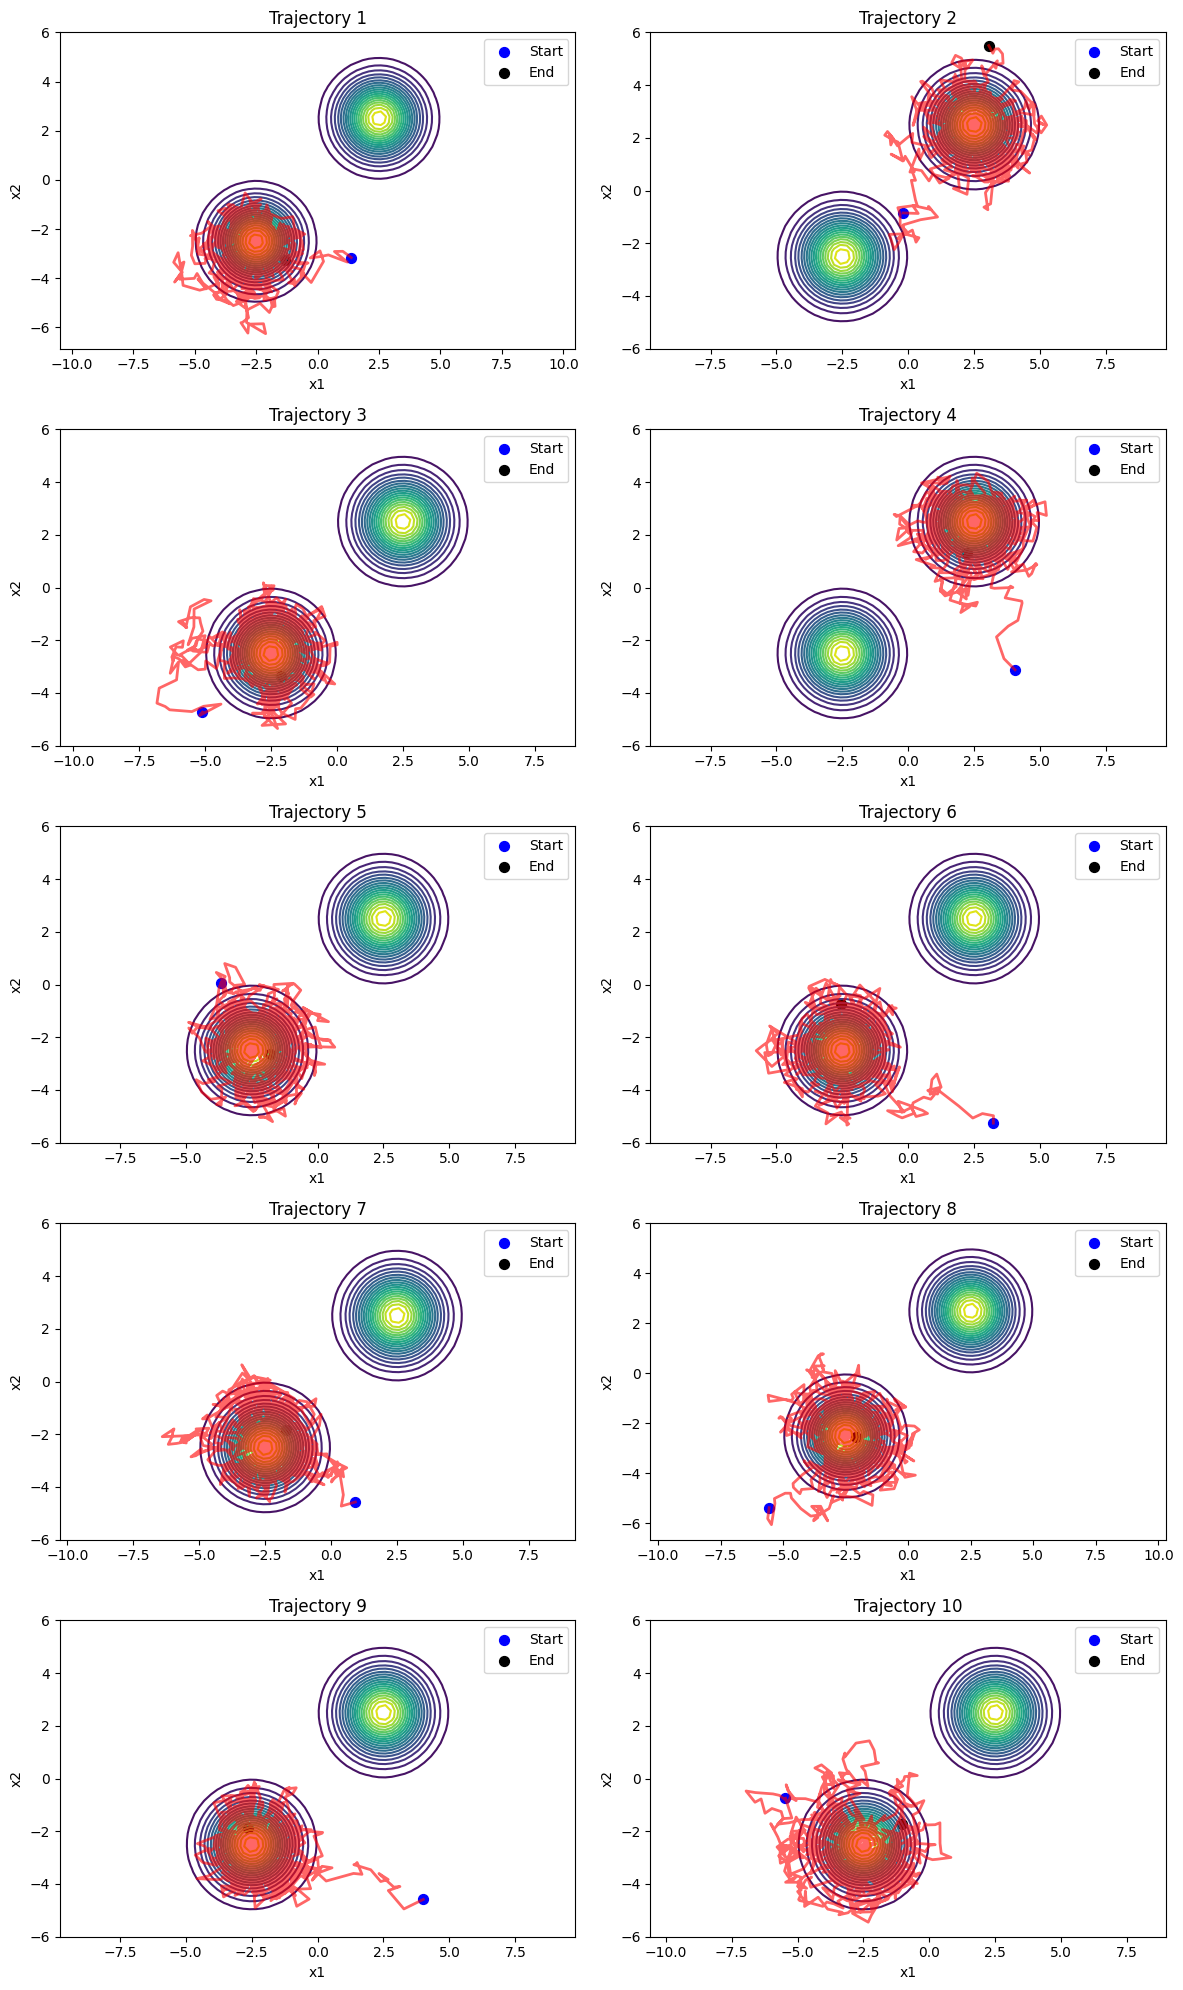

In [5]:
points = np.random.uniform(low=-6, high=6, size=(10, 2))

fig, axes = plt.subplots(5, 2, figsize=(12, 20))  # 5 rows, 2 cols
axes = axes.flatten()  # flatten to 1D array for easy indexing

for i, x0 in enumerate(points):
    ax = axes[i]
    trajectory = langevin_dynamics(x0, weights, means, cov, n_steps=1000, eps=0.05)
    
    # Density contours
    ax.contour(X, Y, Z, levels=20, cmap="viridis")
    
    # Trajectory
    ax.plot(trajectory[:,0], trajectory[:,1], color="red", lw=2, alpha=0.6)
    ax.scatter(trajectory[0,0], trajectory[0,1], color="blue", s=50, label="Start")
    ax.scatter(trajectory[-1,0], trajectory[-1,1], color="black", s=50, label="End")
    
    ax.set_title(f"Trajectory {i+1}")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.legend()
    ax.axis("equal")


plt.tight_layout()
plt.show()

## GAUSSIAN ARE NOT SEPARATED

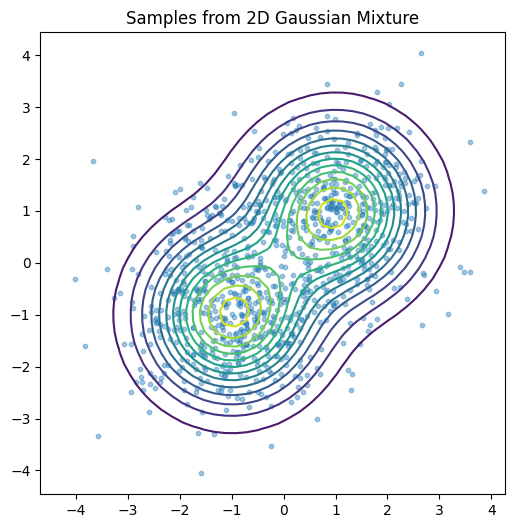

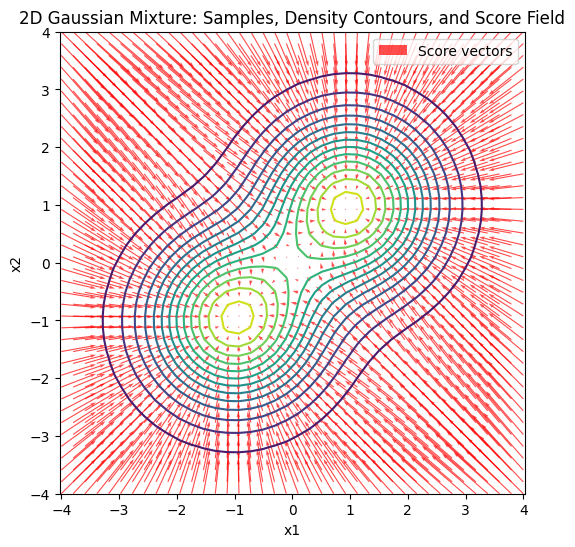

In [6]:
means = [np.array([1.0, 1.0]), np.array([-1.0, -1.0])]
cov = np.array([[1.0, 0.0],
                [0.0, 1.0]])   # same covariance for both
weights = [0.5, 0.5]

# samples
samples = sample_gmm(weights, means, cov, 1000)

# contours and scores
grid_x_v = np.linspace(-4, 4, 40)
grid_y_v = np.linspace(-4, 4, 40)
X, Y, Z, U, V = get_scores_and_contours(weights, means, cov, grid_x_v, grid_y_v)

# Plot samples and contours
plt.figure(figsize=(6,6))
plt.contour(X, Y, Z, levels=15, cmap="viridis")
plt.scatter(samples[:,0], samples[:,1], s=10, alpha=0.4)
plt.title("Samples from 2D Gaussian Mixture")
plt.axis("equal")
plt.show()

# Contours and scores
plt.figure(figsize=(6,6))
plt.contour(X, Y, Z, levels=15, cmap="viridis")
plt.quiver(X, Y, U, V, color="red", angles="xy", scale_units="xy", scale=5, alpha=0.7, label="Score vectors")
plt.title("2D Gaussian Mixture: Samples, Density Contours, and Score Field")
plt.xlabel("x1")
plt.ylabel("x2")
plt.axis("equal")
plt.legend()
plt.show()

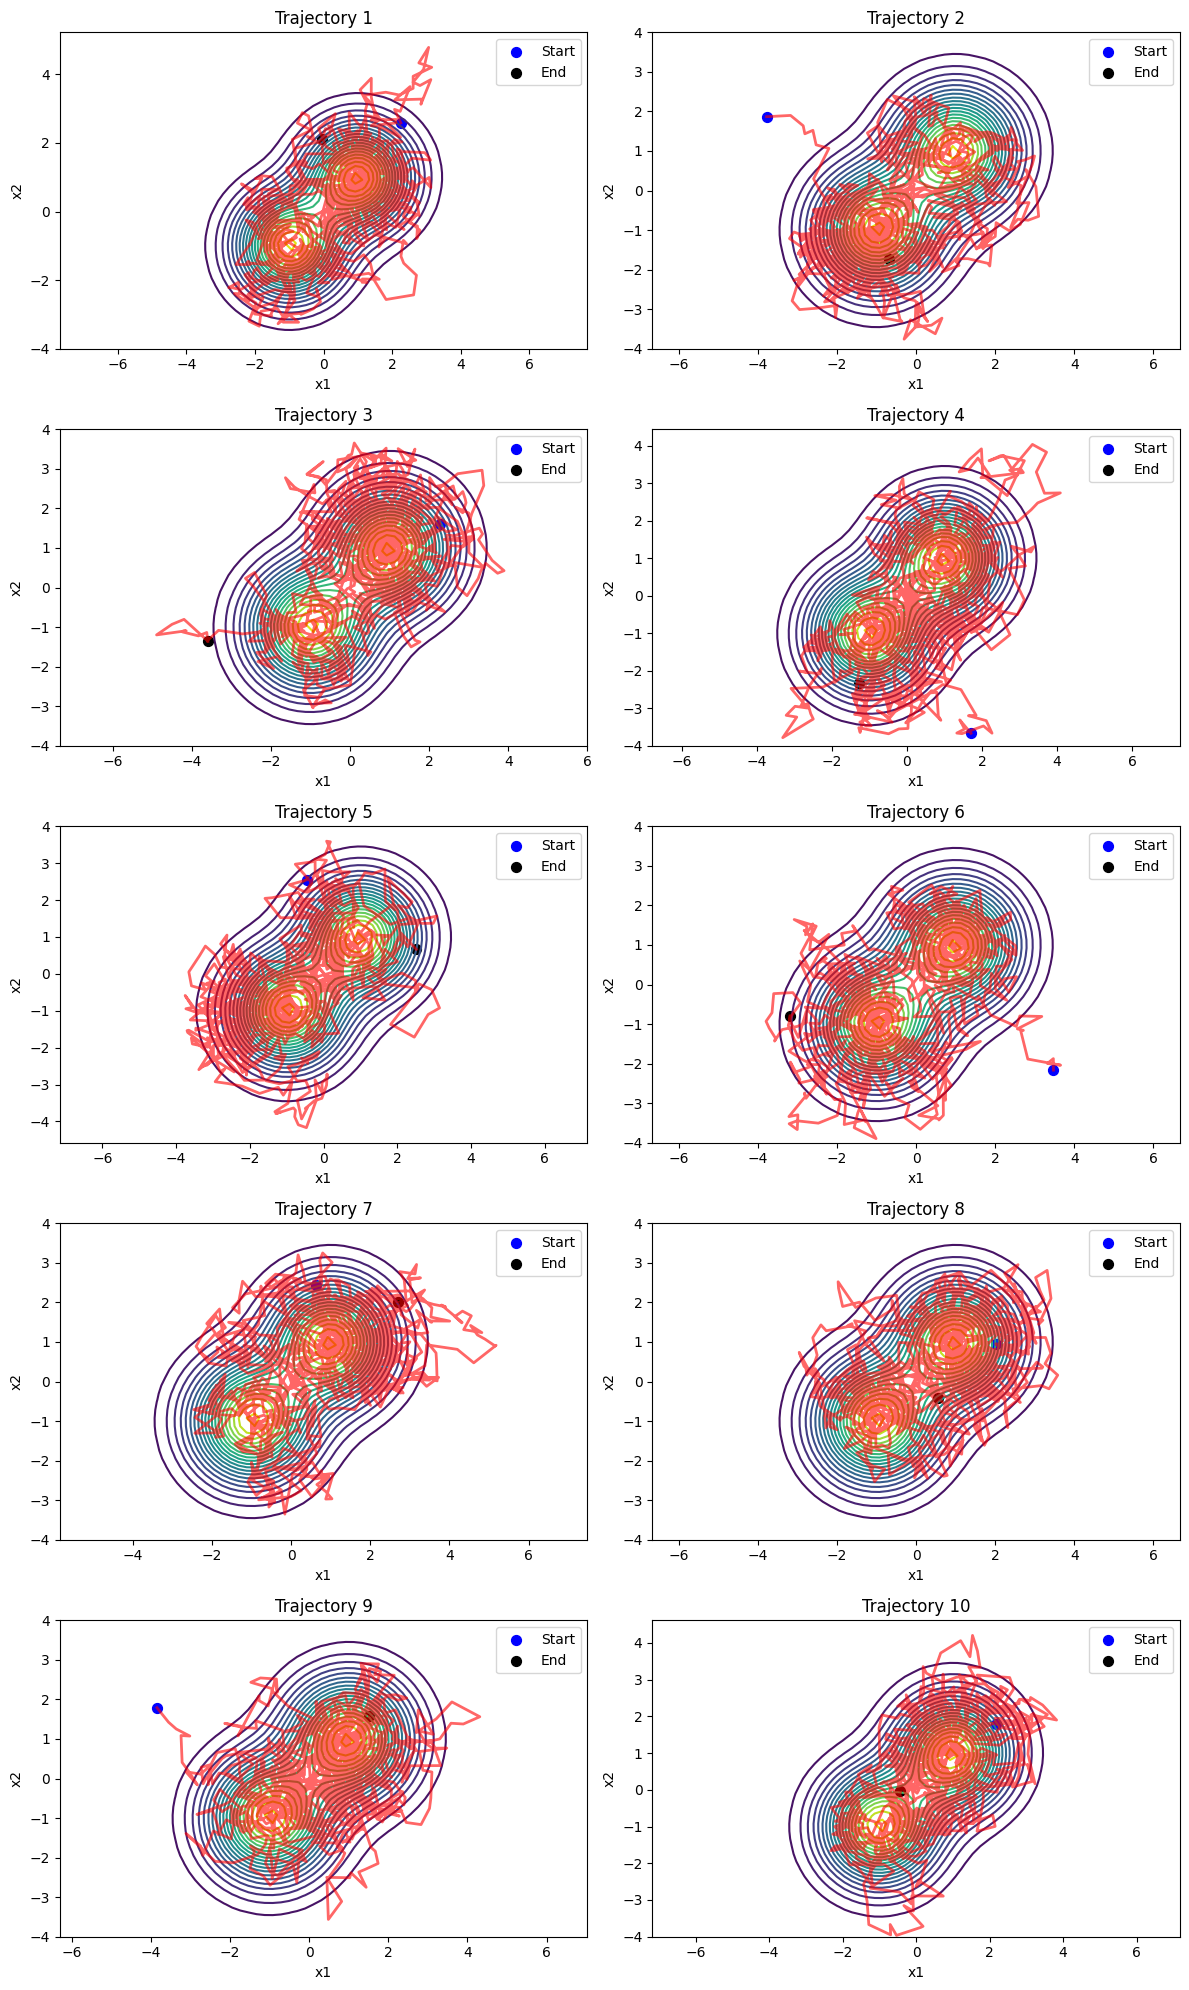

In [7]:
points = np.random.uniform(low=-4, high=4, size=(10, 2))

fig, axes = plt.subplots(5, 2, figsize=(12, 20))  # 5 rows, 2 cols
axes = axes.flatten()  # flatten to 1D array for easy indexing

for i, x0 in enumerate(points):
    ax = axes[i]
    trajectory = langevin_dynamics(x0, weights, means, cov, n_steps=1000, eps=0.05)
    
    # Density contours
    ax.contour(X, Y, Z, levels=20, cmap="viridis")
    
    # Trajectory
    ax.plot(trajectory[:,0], trajectory[:,1], color="red", lw=2, alpha=0.6)
    ax.scatter(trajectory[0,0], trajectory[0,1], color="blue", s=50, label="Start")
    ax.scatter(trajectory[-1,0], trajectory[-1,1], color="black", s=50, label="End")
    
    ax.set_title(f"Trajectory {i+1}")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.legend()
    ax.axis("equal")

plt.tight_layout()
plt.show()

## GAUSSIANS ARE ILL CONDITIONED

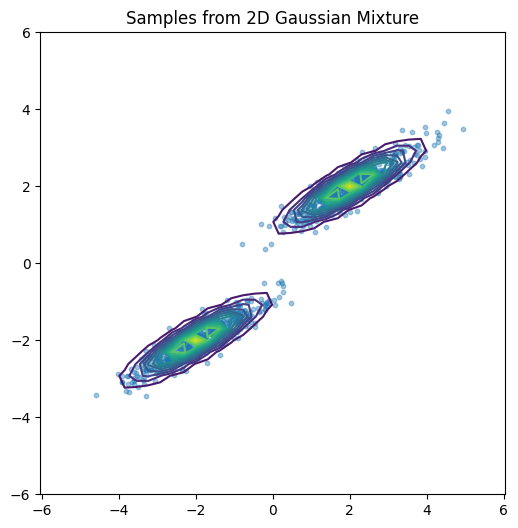

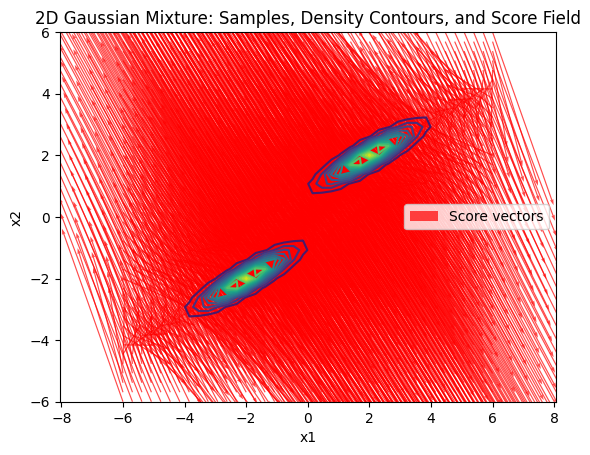

In [8]:
means = [np.array([2.0, 2.0]), np.array([-2.0, -2.0])]
weights = [0.5, 0.5]

theta = np.pi / 6  # rotation angle to make it non-diagonal
R = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta),  np.cos(theta)]
])

eigs = np.diag([1, 5e-2])      # large condition number
cov = R @ eigs @ R.T       # rotate to avoid purely axis-aligned


# samples
samples = sample_gmm(weights, means, cov, 1000)

# contours and scores
grid_x_v = np.linspace(-6, 6, 40)
grid_y_v = np.linspace(-6, 6, 40)
X, Y, Z, U, V = get_scores_and_contours(weights, means, cov, grid_x_v, grid_y_v)

# Plot samples and contours
plt.figure(figsize=(6,6))
plt.contour(X, Y, Z, levels=15, cmap="viridis")
plt.scatter(samples[:,0], samples[:,1], s=10, alpha=0.4)
plt.title("Samples from 2D Gaussian Mixture")
plt.axis("equal")
plt.show()

# Contours and scores
plt.figure(figsize=(6,6))
plt.contour(X, Y, Z, levels=15, cmap="viridis")
plt.quiver(X, Y, U, V, color="red", angles="xy", scale_units="xy", scale=5, alpha=0.7, label="Score vectors")
plt.title("2D Gaussian Mixture: Samples, Density Contours, and Score Field")
plt.xlabel("x1")
plt.ylabel("x2")
plt.axis("equal")
plt.legend()
plt.show()

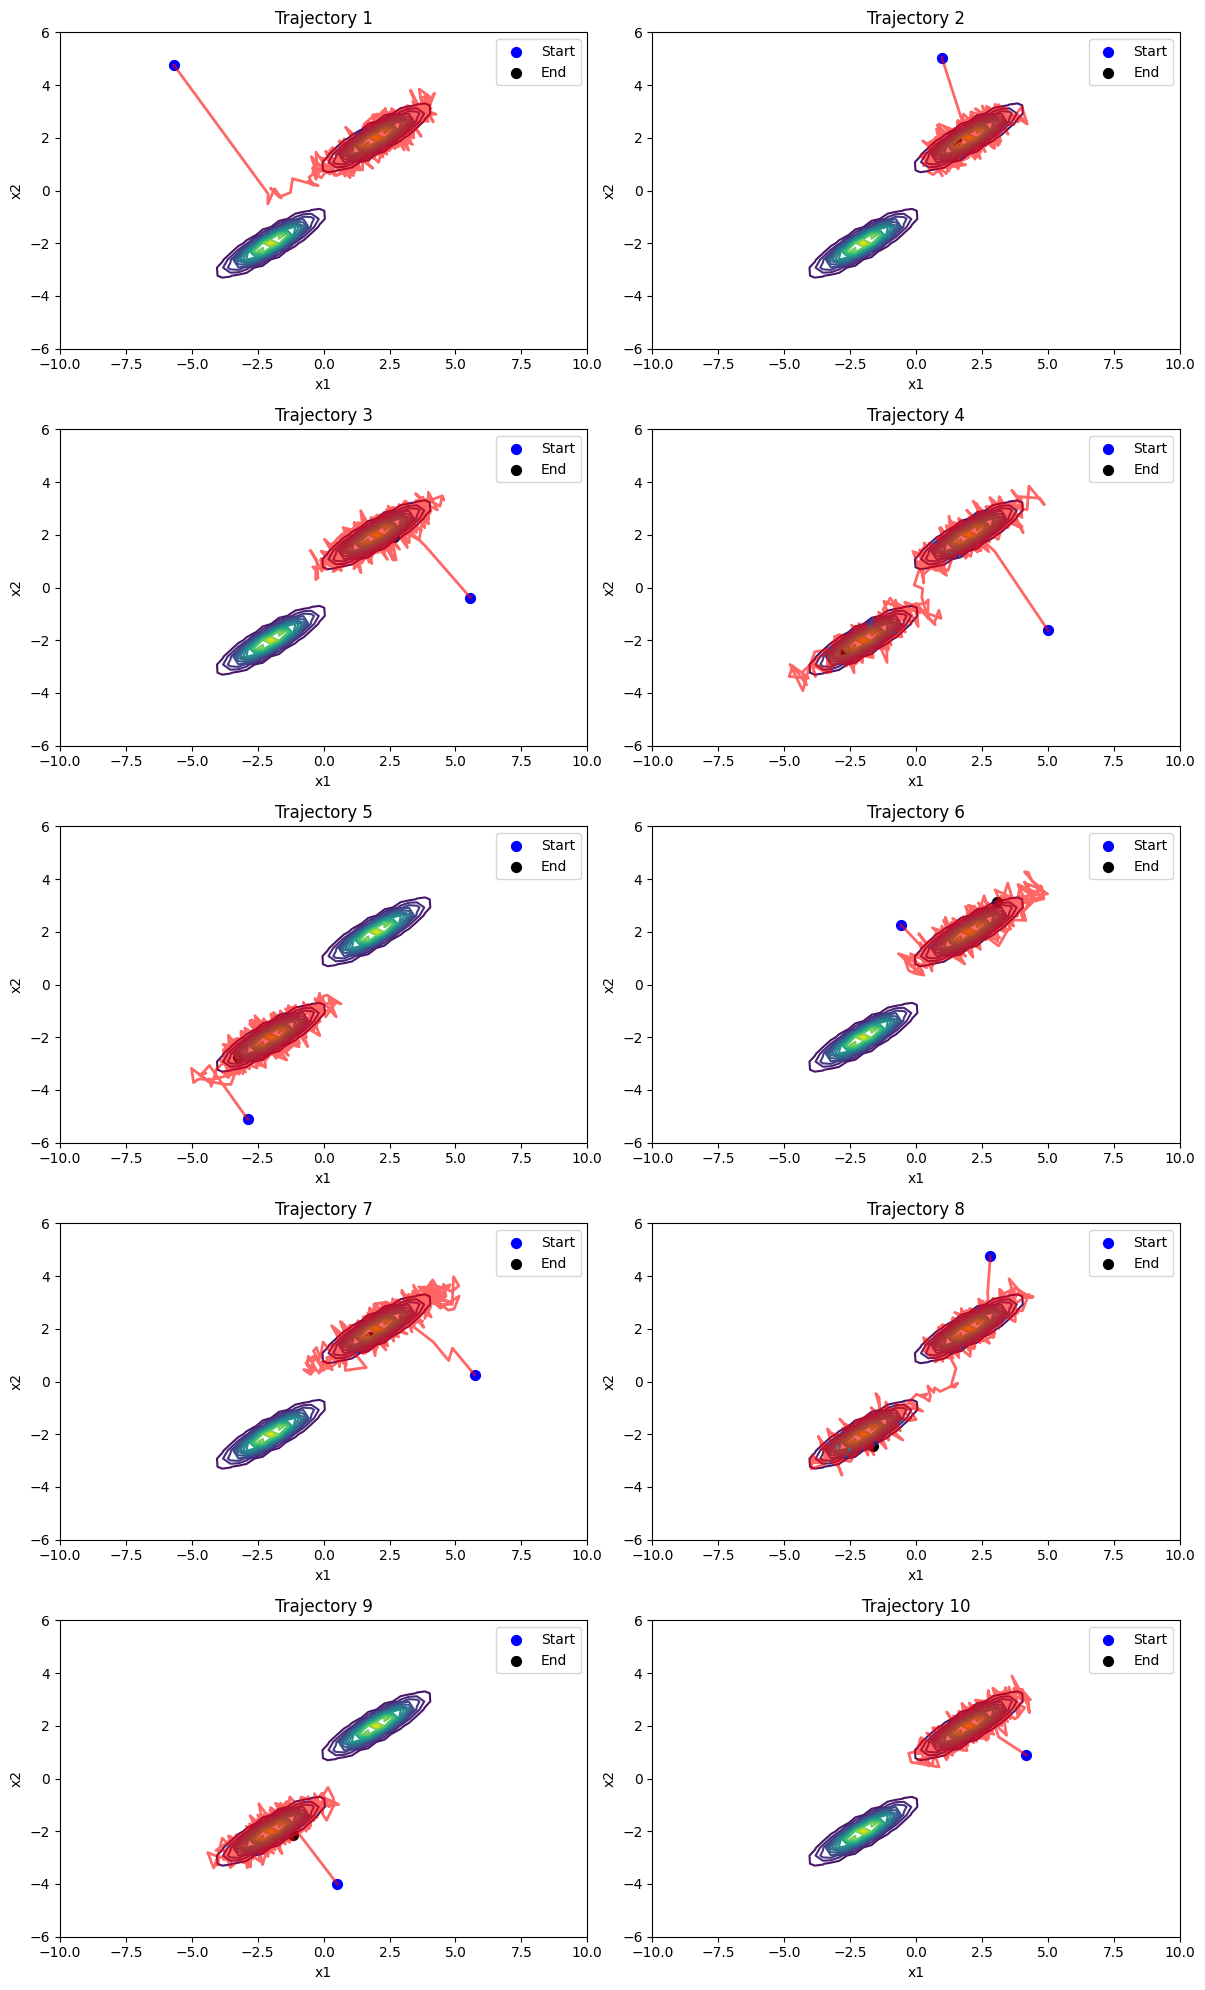

In [9]:
points = np.random.uniform(low=-6, high=6, size=(10, 2))

fig, axes = plt.subplots(5, 2, figsize=(12, 20))  # 5 rows, 2 cols
axes = axes.flatten()  # flatten to 1D array for easy indexing

for i, x0 in enumerate(points):
    ax = axes[i]
    trajectory = langevin_dynamics(x0, weights, means, cov, n_steps=1000, eps=0.05)
    
    # Density contours
    ax.contour(X, Y, Z, levels=20, cmap="viridis")
    
    # Trajectory
    ax.plot(trajectory[:,0], trajectory[:,1], color="red", lw=2, alpha=0.6)
    ax.scatter(trajectory[0,0], trajectory[0,1], color="blue", s=50, label="Start")
    ax.scatter(trajectory[-1,0], trajectory[-1,1], color="black", s=50, label="End")
    
    ax.set_title(f"Trajectory {i+1}")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.legend()
    ax.axis("equal")


plt.tight_layout()
plt.show()

## GAUSSIAN ARE SEPARATED - DIFFERENT MIXTURE WEIGHTS

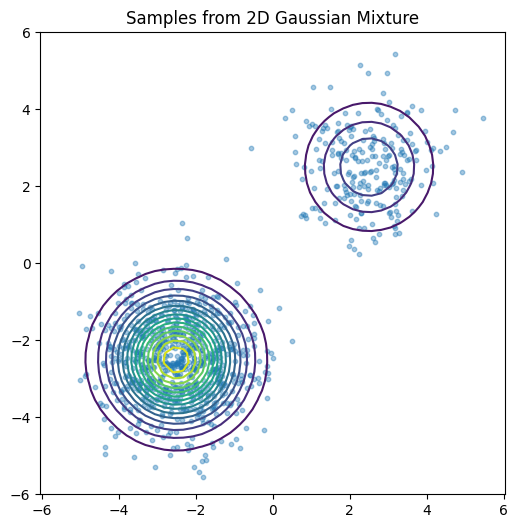

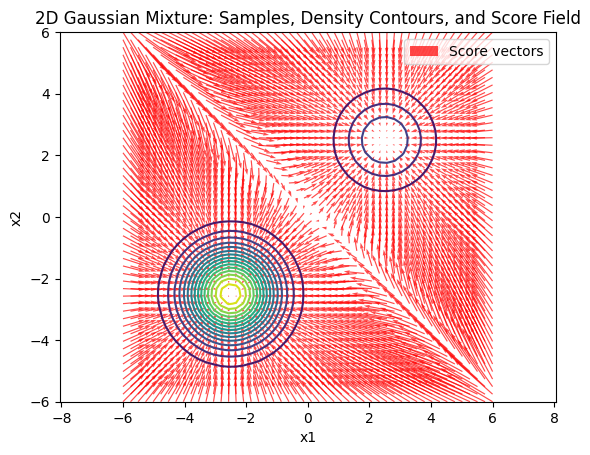

In [10]:
means = [np.array([2.5, 2.5]), np.array([-2.5, -2.5])]
cov = np.array([[1.0, 0.0],
                [0.0, 1.0]])   # same covariance for both
weights = [0.2, 0.8]

# samples
samples = sample_gmm(weights, means, cov, 1000)

# contours and scores
grid_x_v = np.linspace(-6, 6, 50)
grid_y_v = np.linspace(-6, 6, 50)
X, Y, Z, U, V = get_scores_and_contours(weights, means, cov, grid_x_v, grid_y_v)

# Plot samples and contours
plt.figure(figsize=(6,6))
plt.contour(X, Y, Z, levels=15, cmap="viridis")
plt.scatter(samples[:,0], samples[:,1], s=10, alpha=0.4)
plt.title("Samples from 2D Gaussian Mixture")
plt.axis("equal")
plt.show()

# Contours and scores
plt.figure(figsize=(6,6))
plt.contour(X, Y, Z, levels=15, cmap="viridis")
plt.quiver(X, Y, U, V, color="red", angles="xy", scale_units="xy", scale=5, alpha=0.7, label="Score vectors")
plt.title("2D Gaussian Mixture: Samples, Density Contours, and Score Field")
plt.xlabel("x1")
plt.ylabel("x2")
plt.axis("equal")
plt.legend()
plt.show()

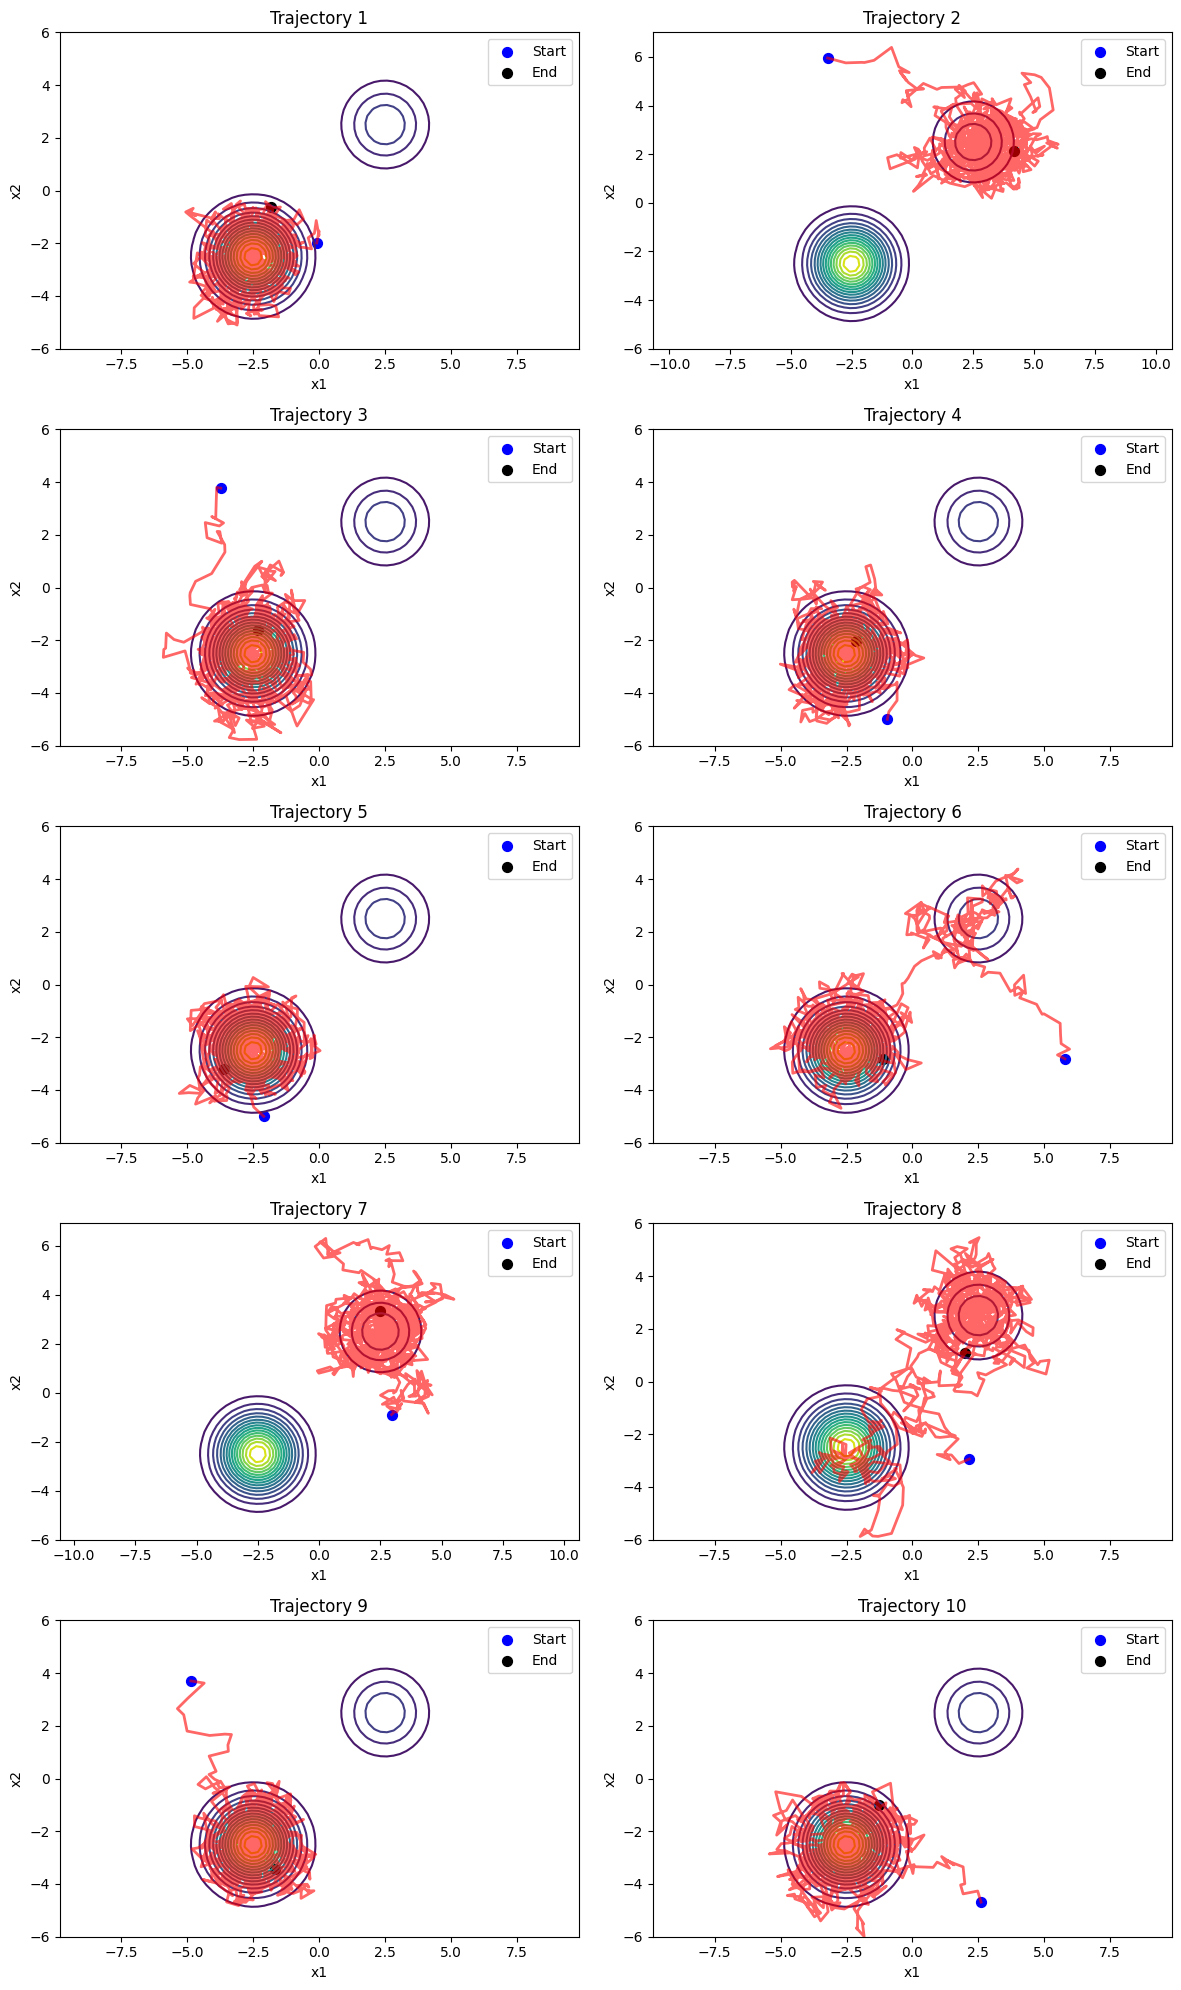

In [11]:
points = np.random.uniform(low=-6, high=6, size=(10, 2))

fig, axes = plt.subplots(5, 2, figsize=(12, 20))  # 5 rows, 2 cols
axes = axes.flatten()  # flatten to 1D array for easy indexing

for i, x0 in enumerate(points):
    ax = axes[i]
    trajectory = langevin_dynamics(x0, weights, means, cov, n_steps=1000, eps=0.05)
    
    # Density contours
    ax.contour(X, Y, Z, levels=20, cmap="viridis")
    
    # Trajectory
    ax.plot(trajectory[:,0], trajectory[:,1], color="red", lw=2, alpha=0.6)
    ax.scatter(trajectory[0,0], trajectory[0,1], color="blue", s=50, label="Start")
    ax.scatter(trajectory[-1,0], trajectory[-1,1], color="black", s=50, label="End")
    
    ax.set_title(f"Trajectory {i+1}")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.legend()
    ax.axis("equal")

plt.tight_layout()
plt.show()

Sample 1000 points using langevin dynamics.

In [12]:
points = np.random.uniform(low=-6, high=6, size=(1000, 2))

sampled = []
for i, x0 in enumerate(points):
    trajectory = langevin_dynamics(x0, weights, means, cov, n_steps=1000, eps=0.05)
    sampled.append(trajectory[-1])
    if (i + 1) % 100 == 0:
        print(f"Sampled {i + 1} points")

sampled = np.array(sampled)
print(sampled.shape)

Sampled 100 points
Sampled 200 points
Sampled 300 points
Sampled 400 points
Sampled 500 points
Sampled 600 points
Sampled 700 points
Sampled 800 points
Sampled 900 points
Sampled 1000 points
(1000, 2)


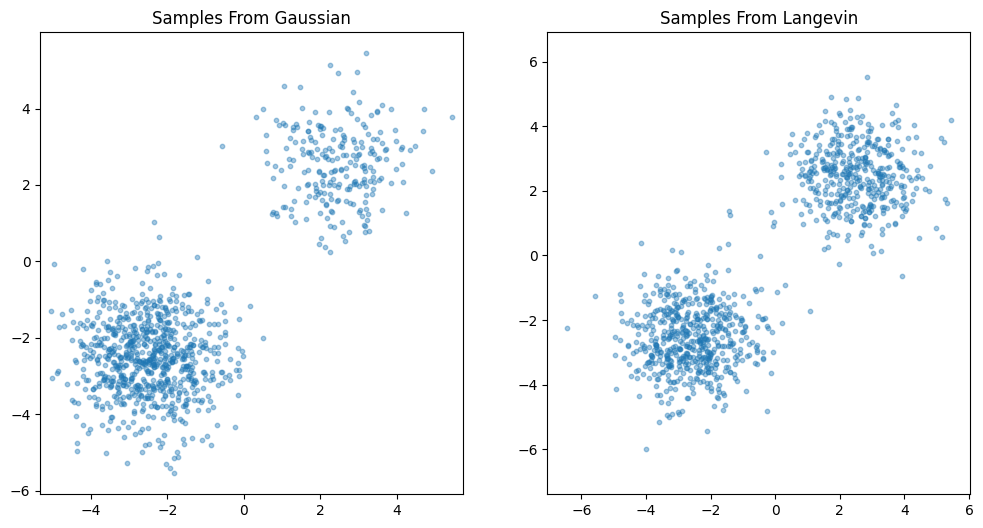

In [13]:
# Plot samples and contours
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.scatter(samples[:,0], samples[:,1], s=10, alpha=0.4)
plt.title("Samples From Gaussian")
plt.axis("equal")

plt.subplot(1, 2, 2)
plt.scatter(sampled[:,0], sampled[:,1], s=10, alpha=0.4)
plt.title("Samples From Langevin")
plt.axis("equal")

plt.show()

As you can see that even though mixtures weights are different - plain langevin dynamics kind of doesn't retrive the original mixture weights.

In [14]:
def langevin_dynamics_v2(x0, weights, means, cov, n_steps=1000, eps_init=0.05):
    traj = [x0]
    x = x0.copy()
    for idx in range(n_steps):
        score = gmm_score(x, weights, means, cov)
        noise = np.random.randn(2)
        eps = eps_init + ((eps_init / 100 - eps_init) / (n_steps - 1)) * idx
        x = x + eps * score + np.sqrt(2 * eps) * noise
        traj.append(x)

    return np.array(traj)